In [1]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload mode
%autoreload 2

# CoralNet Annotation EDA

In [3]:
import io
import pandas as pd
import numpy as np 

import tqdm
import warnings

from matplotlib import pyplot as plt

In [4]:
import boto3

import requests 
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse

def check_s3_prefix_exists(bucket_name, s3_prefix, source_id, specific_file = "annotations.csv"):
    s3 = boto3.client("s3")
    prefix = f"{s3_prefix}/s{source_id}/{specific_file}"

    response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix, MaxKeys=1)

    if "Contents" in response:
        # print(f"Prefix exists: {prefix}")
        return True
    else:
        # print(f"Prefix does not exist: {prefix}")
        return False

In [5]:
#Map to CoralNet labelspace

mapping_endpoint ="https://api.datamermaid.org/v1/classification/labelmappings/?provider=CoralNet" 

response = requests.get(mapping_endpoint)
data = response.json()
labelset = data["results"]

while data["next"]:
    response = requests.get(data["next"])
    data = response.json()
    labelset.extend(data["results"])
label_mapping = {
    int(label["provider_id"]): label["benthic_attribute_name"] for label in labelset
}

# Source EDA

In [6]:
### Get all publicly available CoralNet sources
url = "https://coralnet.ucsd.edu/source/about/"

resp = requests.get(url, timeout=50)
resp.raise_for_status()

soup = BeautifulSoup(resp.text, "html.parser")
anchors = soup.find_all("a", href=True)

links = sorted(
    {
        urljoin(url, a["href"])
        for a in anchors
        if urlparse(urljoin(url, a["href"])).scheme in ("http", "https")
    }
)

print("Found", len(links), "links on the page.")
source_links = [link for link in links if "/source/" in link]
print("Found", len(source_links), "links on the page.")
all_coralnet_sources = sorted({int(link.split("/")[-2]) for link in source_links})

Found 1977 links on the page.
Found 1967 links on the page.


In [7]:
# s3 = boto3.client("s3")

# bucket_name = "dev-datamermaid-sm-sources"
# prefix = "coralnet-public-images"

# data = []
# for i, source_id in tqdm.tqdm(enumerate(all_coralnet_sources)):

#     annotations_flag = check_s3_prefix_exists(
#         bucket_name=bucket_name, s3_prefix=prefix, source_id=source_id, specific_file="annotations.csv"
#     )
#     if annotations_flag:
#         s3_key_annotations = f"{prefix}/s{source_id}/annotations.csv"
#         obj_ann = s3.get_object(Bucket=bucket_name, Key=s3_key_annotations)
#         annotations_df = pd.read_csv(obj_ann["Body"])
#         image_count = annotations_df["Name"].nunique()
#         num_labels = annotations_df["Label ID"].nunique()
#         num_labels_mapped = annotations_df["Label ID"].map(label_mapping).nunique()
#         data.append((source_id, image_count, annotations_df.shape[0], num_labels, num_labels_mapped))
#     else:
#         data.append((source_id, 0, 0, 0, 0))

# df_source = pd.DataFrame(data, columns = ["source_id", "image_count", "annotations_count", "num_labels", "num_labels_MERMAID"])
# df_source.to_csv("dataframes/coralnet_source_description.csv", index=False)

df_source = pd.read_csv("dataframes/coralnet_source_description.csv")

In [8]:
df_source.head()

,source_id,image_count,annotations_count,num_labels,num_labels_MERMAID
0,23,750,15000,20,16
1,57,1681,168100,27,20
2,69,100,4000,5,5
3,70,300,12000,16,16
4,82,0,0,0,0


In [9]:
# Drop Sources that Haven't Been scraped (Have no images)
df_source = df_source[df_source["image_count"] > 0]

In [10]:
df_source.shape

(1324, 5)

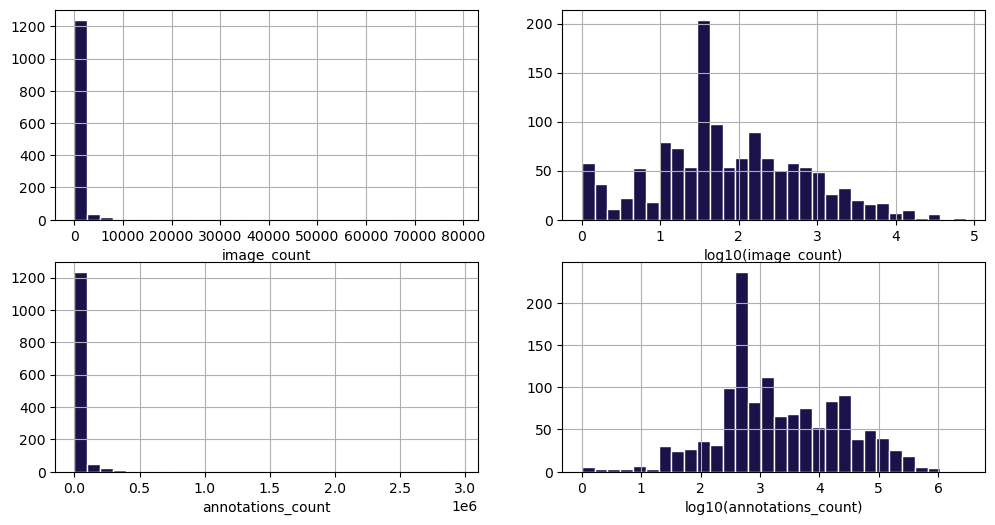

In [23]:
fig, ax = plt.subplots(figsize=(12, 6), nrows = 2, ncols = 2)
df_source["image_count"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[0,0])
ax[0, 0].set_xlabel("image_count")

np.log10(df_source["image_count"]).hist(
    bins=30, edgecolor="white", color="#1C124A", ax=ax[0, 1]
)
ax[0, 1].set_xlabel("log10(image_count)")

df_source["annotations_count"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[1,0])
ax[1,0].set_xlabel("annotations_count")

np.log10(df_source["annotations_count"]).hist(
    bins=30, edgecolor="white", color="#1C124A", ax=ax[1, 1]
)
ax[1, 1].set_xlabel("log10(annotations_count)")
plt.show()

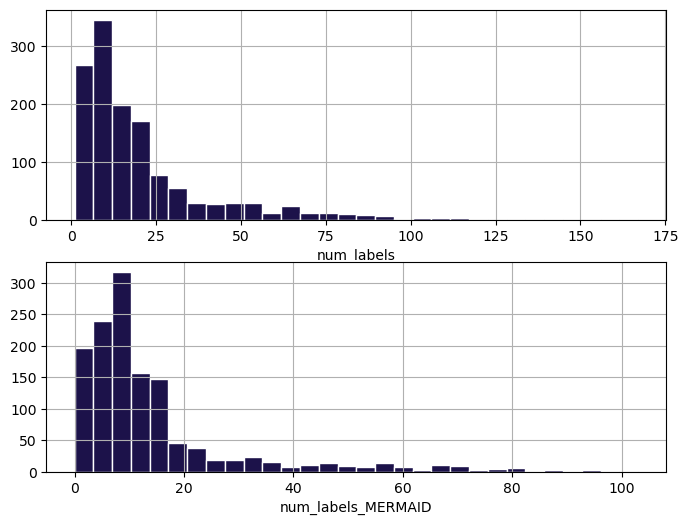

In [24]:
fig, ax = plt.subplots(figsize=(8, 6), nrows = 2)
df_source["num_labels"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[0])
ax[0].set_xlabel("num_labels")


df_source["num_labels_MERMAID"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[1])
ax[1].set_xlabel("num_labels_MERMAID")
plt.show()

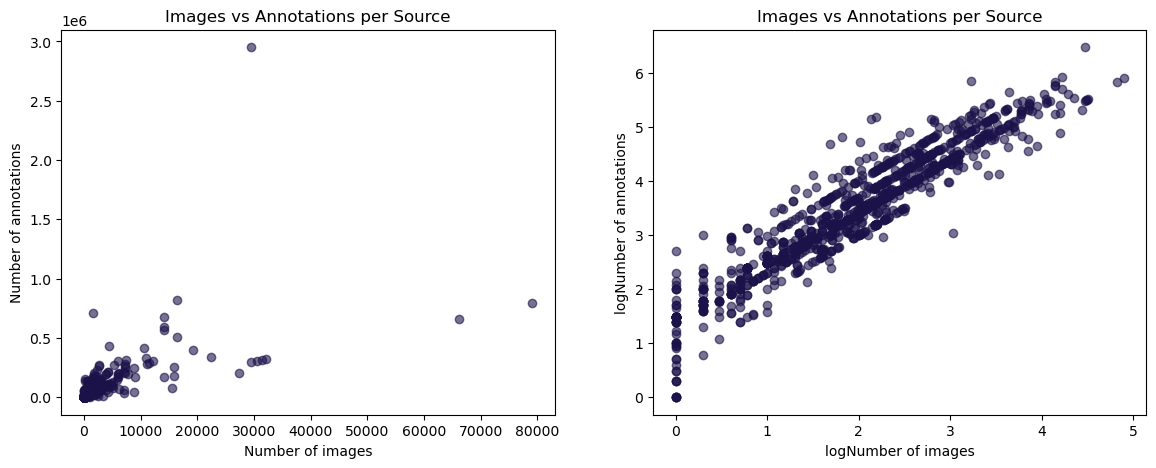

In [28]:
fig, ax = plt.subplots(figsize=(14, 5), ncols = 2)
ax[0].scatter(
    df_source["image_count"],
    df_source["annotations_count"],
    alpha=0.6,
    color="#1C124A"
)   

ax[0].set_xlabel("Number of images")
ax[0].set_ylabel("Number of annotations")
ax[0].set_title("Images vs Annotations per Source")

ax[1].scatter(
    np.log10(df_source["image_count"]),
    np.log10(df_source["annotations_count"]),
    alpha=0.6,
    color="#1C124A"
)   

ax[1].set_xlabel("logNumber of images")
ax[1].set_ylabel("logNumber of annotations")
ax[1].set_title("Images vs Annotations per Source")
plt.show()

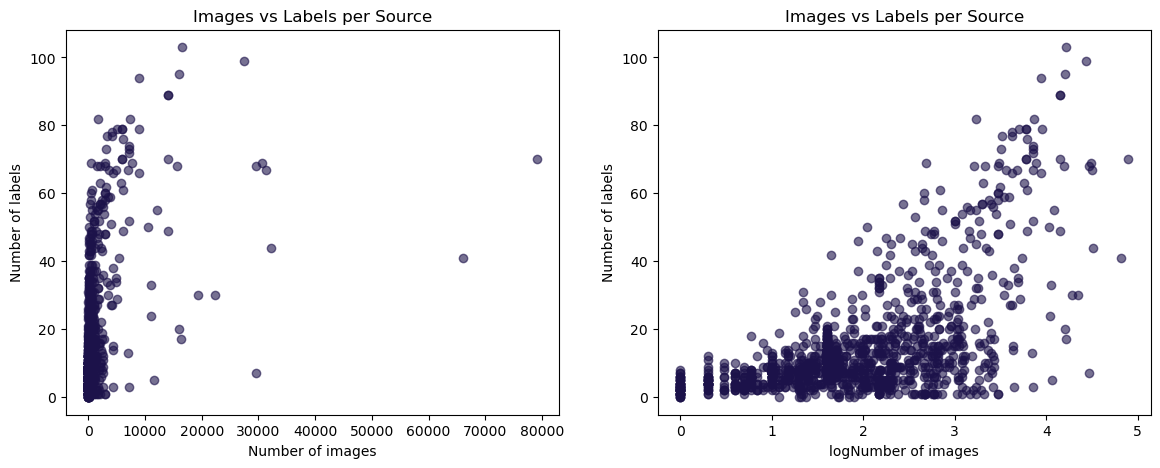

In [35]:
fig, ax = plt.subplots(figsize=(14, 5), ncols = 2)
ax[0].scatter(
    df_source["image_count"],
    df_source["num_labels_MERMAID"],
    alpha=0.6,
    color="#1C124A"
)   
    
ax[0].set_xlabel("Number of images")
ax[0].set_ylabel("Number of labels")
ax[0].set_title("Images vs Labels per Source")

ax[1].scatter(
    np.log10(df_source["image_count"]),
    df_source["num_labels_MERMAID"],
    alpha=0.6,
    color="#1C124A"
)   

ax[1].set_xlabel("logNumber of images")
ax[1].set_ylabel("Number of labels")
ax[1].set_title("Images vs Labels per Source")
plt.show()

In [36]:
num_images_threshold = 20
num_annotations_threshold = 500
num_labels_threshold = 30
num_labels_MERMAID_threshold = 30

In [48]:
print(f"Sources with more than {num_images_threshold} images: {(df_source['image_count'] > num_images_threshold).sum()}")
print(f"Sources with more than {num_annotations_threshold} annotations: {(df_source['annotations_count'] > num_annotations_threshold).sum()}")
print(f"Sources with more than {num_labels_threshold} labels: {(df_source['num_labels'] > num_labels_threshold).sum()}")
print(f"Sources with more than {num_labels_MERMAID_threshold} MERMAID mapped labels: {(df_source['num_labels_MERMAID'] > num_labels_MERMAID_threshold).sum()}")

Sources with more than 20 images: 974
Sources with more than 500 annotations: 1010
Sources with more than 30 labels: 242
Sources with more than 30 MERMAID mapped labels: 148


In [49]:
print(f"Sources with all requirements (original): {((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] > num_annotations_threshold) & 
                                        (df_source['num_labels'] > num_labels_threshold)).sum()}")

Sources with all requirements (original): 239


In [50]:
print(f"Sources with all requirements (MERMAID): {((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] > num_annotations_threshold) & 
                                        (df_source['num_labels_MERMAID'] > num_labels_MERMAID_threshold)).sum()}")

Sources with all requirements (MERMAID): 148


In [51]:
num_images_threshold = 100
num_annotations_threshold = 1000
num_labels_MERMAID_threshold = 10

print(f"Sources with all updated (example) requirements (MERMAID): {((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] > num_annotations_threshold) & 
                                        (df_source['num_labels_MERMAID'] > num_labels_MERMAID_threshold)).sum()}")

Sources with all updated (example) requirements (MERMAID): 340


## Source Quality
Here we explore the manual quality annotations of CoralNet sources. This was done for 192 sources out of a pool of 1377 sources, selected with the following criteria:
- \>20 images 
- \>500 annotations
- \>30 labels (This might be a too strict requirement. We should also think about whether we are counting the number of original labels, or the number of labels after mapping to our labelset of interest).
- \>50% classifier accuracy within CoralNet (We may want to remove this requirement alltogether, since we might be missing more difficult sources, sources with a lot of different labels, especially ones with a balanced distribution).

The sources were evaluated on the quality of the images (ImageQuality, 1-5), diversity of corals (CoralDiversity, 1-5) with a final boolean variable on whether they should be kept or not (ToKeep). On top of that the affiliation, description and location are noted down for each source (that has one).

Link: https://docs.google.com/spreadsheets/d/1CEhheXyGyNeLZT2_GZncuCakBM1XMosWPgvnNA2TLdo/edit?gid=854366795#gid=854366795

In [20]:
df_source_quality = pd.read_csv("dataframes/coralnet_source_quality.csv") # The file can be downloaded on the above link as well

In [21]:
# The latitude and longitude are usually 0,0 or 1,1 for sources where it is not explicitly defined. 
df_source_quality.loc[((df_source_quality["Latitude"]==0)+(df_source_quality["Latitude"]==1))*
                      ((df_source_quality["Longitude"]==0)+(df_source_quality["Longitude"]==1)),
                      ["Latitude", "Longitude"]] = np.nan

In [22]:
df_source_quality.head(3)

,Source ID,Source name,Confirmed images,Total points in confirmed images,Unique labels in confirmed images,Date created,Last update in confirmed images,Classifier accuracy,Classifier feature type,Classifier training images,...,Longitude,Affiliation,Description,Link,ToKeep,ImageQuality,CoralDiversity,ToKeepNotes,InS3,InZip
0,1968,Biofouling on the offshore oil platform in the...,184,41400,138,2020-06-23,2020-09-17,59,vgg16_coralnet_ver1,184,...,-91.962410,Universidad Auton贸ma de Yucat谩n,This project aims to analyze the fauna associa...,https://coralnet.ucsd.edu/source/1968/,Yes,5,3,One photo (1782679.jpg) has very low diversity,True,True
1,2855,Kaua驶i_Hanalei,399,9975,46,2021-11-23,2026-01-26,75,efficientnet_b0_ver1,347,...,-159.509675,DLNR-Aquatics,Photos from the Coral Reef Assessment Monitori...,https://coralnet.ucsd.edu/source/2855/,No,5,1,No coral in the photos,True,True
2,3581,NFWF Project,4069,216245,69,2022-10-26,2024-02-16,75,efficientnet_b0_ver1,3113,...,-65.300987,FIU,Percent cover estimates for Punta Maguey and P...,https://coralnet.ucsd.edu/source/3581/,No,4,1,Mostly sand and macroalgae,True,True


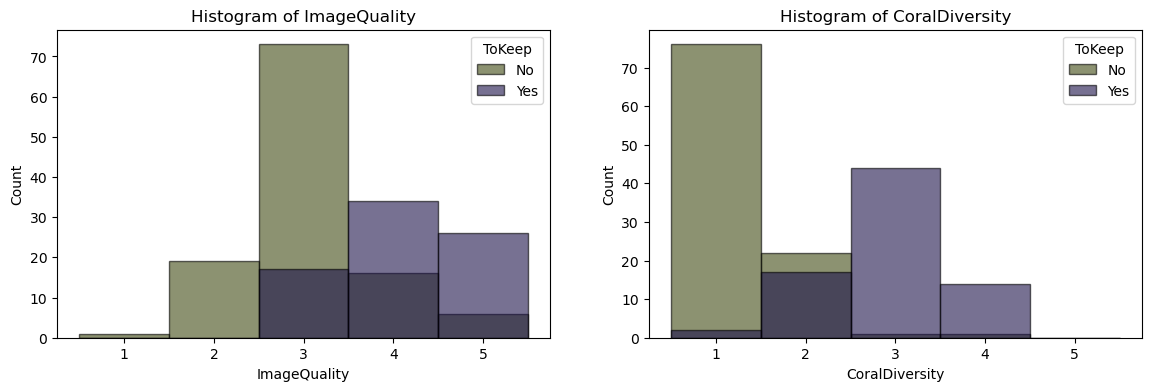

In [23]:
fig, ax = plt.subplots(figsize=(14, 4), ncols = 2)
for (category, subset), color in zip(df_source_quality.groupby("ToKeep", dropna=False), ["#404a12", "#1C124A"]):
    ax[0].hist(
        subset["ImageQuality"],
        bins=np.arange(0.5, 6.5, 1),
        edgecolor="black",
        alpha=0.6,
        label=str(category),
        color=color
    )
ax[0].legend(title="ToKeep")
ax[0].set_xticks(range(1, 6))
ax[0].set_xlabel("ImageQuality")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of ImageQuality")

for (category, subset), color in zip(df_source_quality.groupby("ToKeep", dropna=False), ["#404a12", "#1C124A"]):
    ax[1].hist(
        subset["CoralDiversity"],
        bins=np.arange(0.5, 6.5, 1),
        edgecolor="black",
        alpha=0.6,
        label=str(category),
        color=color
    )
ax[1].legend(title="ToKeep")
ax[1].set_xticks(range(1, 6))
ax[1].set_xlabel("CoralDiversity")
ax[1].set_ylabel("Count")
ax[1].set_title("Histogram of CoralDiversity")
plt.show()

The geographic distribution of the data is pretty good, however, many of the sources labeled as not ToKeep are the ones in places that could be of particular interest due to generally lower data coverage.

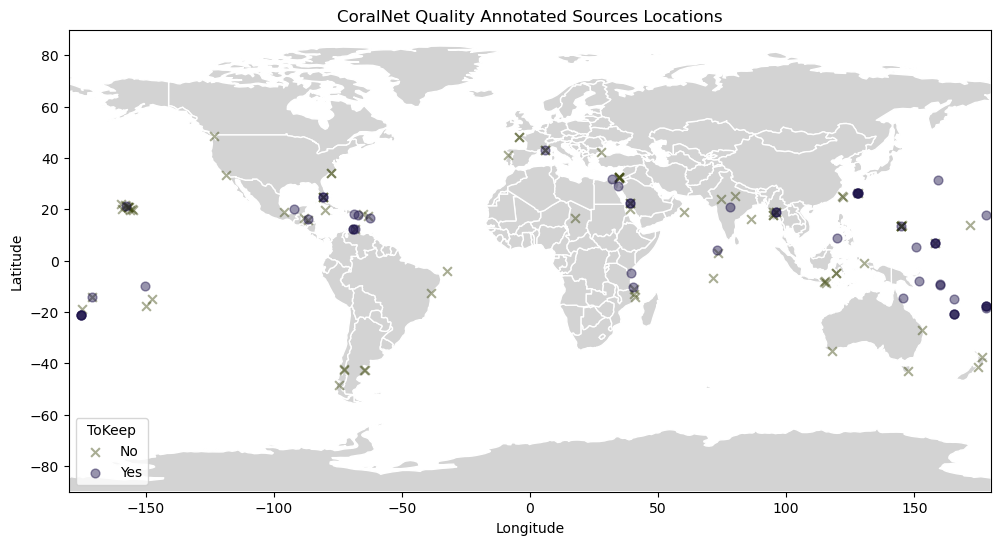

In [17]:
#!pip install geopandas
import geopandas as gpd

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color="lightgray", edgecolor="white")

colors = {"Yes": "#1C124A", "No": "#404a12"}

for keep_value, subset in df_source_quality.groupby("ToKeep", dropna=False):
    ax.scatter(
        subset["Longitude"],
        subset["Latitude"],
        s=40,
        c=colors.get(keep_value, "#666666"),
        alpha=0.45,
        marker={"Yes": "o", "No": "x"}.get(keep_value, "^"),
        label=str(keep_value),
    )

ax.legend(title="ToKeep", loc="lower left")

ax.set_title("CoralNet Quality Annotated Sources Locations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
plt.show()

## Label Distribution

In [3]:
s3 = boto3.client('s3')
bucket_name = 'dev-datamermaid-sm-sources'

In [27]:
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore")

#     folder = "coralnet-public-images/"
#     paginator = s3.get_paginator("list_objects_v2")

#     sub_response = {"CommonPrefixes": []}
#     for page in paginator.paginate(Bucket=bucket_name, Prefix=folder, Delimiter="/"):
#         if "CommonPrefixes" in page:
#             sub_response["CommonPrefixes"].extend(page["CommonPrefixes"])

#     folders_new = [
#         p["Prefix"].replace(folder, "")
#         for p in sub_response.get("CommonPrefixes", [])
#     ]

# with warnings.catch_warnings():
#     labelset2 = set()
#     data2 = []

#     for source in tqdm.tqdm(folders_new):
#         if not source.startswith("s"):
#             continue

#         source_id = source.strip("/").replace("s", "")
#         if not check_s3_prefix_exists(
#             bucket_name=bucket_name,
#             s3_prefix="coralnet-public-images",
#             source_id=source_id,
#             specific_file="annotations.csv",
#         ):
#             continue

#         file_key = f"coralnet-public-images/{source}annotations.csv"
#         obj = s3.get_object(Bucket=bucket_name, Key=file_key)
#         ann_df = pd.read_csv(io.BytesIO(obj["Body"].read()))

#         data2.append([
#             source,
#             len(ann_df),
#             ann_df["Name"].nunique(),
#             ann_df["Label ID"].nunique(),
#         ])
#         labelset2.update(ann_df["Label ID"].unique())

# coralnet_summary_upd_df = pd.DataFrame(data2, columns=['Source', 'Num Annotations', 'Num Images', 'Num Unique Labels'])
# coralnet_summary_upd_df.to_csv("dataframes/coralnet_source_summary.csv", index=False)
coralnet_summary_upd_df = pd.read_csv("dataframes/coralnet_source_summary.csv")

In [25]:
coralnet_summary_upd_df.head()

,Source,Num Annotations,Num Images,Num Unique Labels
0,s1073/,45000,225,27
1,s1076/,41800,209,28
2,s109/,198500,3970,78
3,s1162/,25,5,4
4,s1184/,50,10,7


In [26]:
# df_list = []

# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore")

#     folder = "coralnet-public-images/"
#     paginator = s3.get_paginator("list_objects_v2")

#     sub_response = {"CommonPrefixes": []}
#     for page in paginator.paginate(Bucket=bucket_name, Prefix=folder, Delimiter="/"):
#         if "CommonPrefixes" in page:
#             sub_response["CommonPrefixes"].extend(page["CommonPrefixes"])

#     folders_new = [
#         p["Prefix"].replace(folder, "")
#         for p in sub_response.get("CommonPrefixes", [])
#     ]

# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

#     for source in tqdm.tqdm(folders_new):
#         file_key = f"coralnet-public-images/{source}annotations.csv"

#         try:
#             s3.head_object(Bucket=bucket_name, Key=file_key)
#         except s3.exceptions.ClientError as e:
#             if e.response["Error"]["Code"] == "404":
#                 print(f"File {file_key} not found in bucket")
#                 continue
#             raise

#         obj = s3.get_object(Bucket=bucket_name, Key=file_key)
#         annotations_df = pd.read_csv(io.BytesIO(obj["Body"].read()), low_memory=False)

#         df_tmp = annotations_df.groupby("Label ID").agg(
#             **{
#                 "Num Annotations": ("Label ID", "size"),
#                 "Num Images": ("Name", "nunique"),
#             }
#         ).reset_index()

#         df_tmp["Source ID"] = source[:-1]
#         df_list.append(df_tmp)

# labels_source_df = pd.concat(df_list)
# labels_source_df.to_csv("dataframes/coralnet_per_source_labels_annotations.csv")
labels_source_df = pd.read_csv("dataframes/coralnet_per_source_labels_annotations.csv")

In [28]:
labels_source_df.head()

,Unnamed: 0,Label ID,Num Annotations,Num Images,Source ID
0,0,81,911,57,s1073
1,1,84,4073,101,s1073
2,2,89,1166,35,s1073
3,3,105,827,66,s1073
4,4,124,22420,206,s1073


In [29]:
label_id_summary = (
    labels_source_df
    .groupby("Label ID", as_index=True)
    .agg(
        **{
            "Num Annotations": ("Num Annotations", "sum"),
            "Num Images": ("Num Images", "sum"),
            "Num Sources": ("Source ID", "nunique"),
        }
    )
)
label_id_summary.head()

,Num Annotations,Num Images,Num Sources
Label ID,,,
58,2521,1763,77
59,418545,72003,148
60,18932,9101,111
61,9115,5054,99
62,8614,4900,38


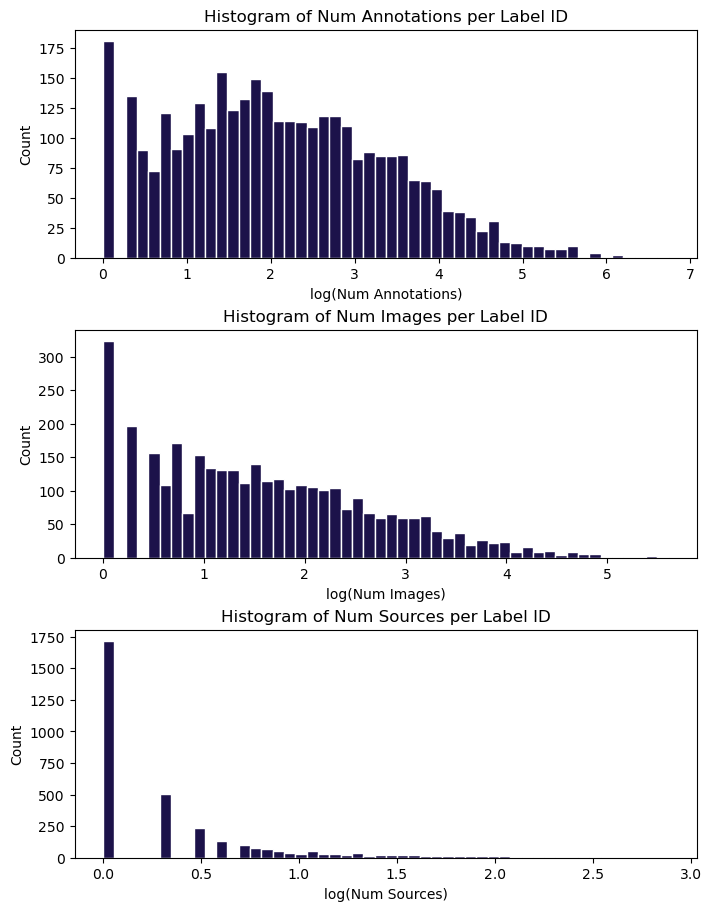

In [30]:
fig, ax = plt.subplots(figsize=(7, 9), nrows = 3, layout = "compressed")
ax[0].hist(np.log10(label_id_summary["Num Annotations"]), bins=50, edgecolor="white", color = "#1C124A")
ax[0].set_xlabel("log(Num Annotations)")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of Num Annotations per Label ID")

ax[1].hist(np.log10(label_id_summary["Num Images"]), bins=50, edgecolor="white", color = "#1C124A")
ax[1].set_xlabel("log(Num Images)")
ax[1].set_ylabel("Count")
ax[1].set_title("Histogram of Num Images per Label ID")

ax[1].hist(np.log10(label_id_summary["Num Images"]), bins=50, edgecolor="white", color = "#1C124A")
ax[1].set_xlabel("log(Num Images)")
ax[1].set_ylabel("Count")
ax[1].set_title("Histogram of Num Images per Label ID")

ax[2].hist(np.log10(label_id_summary["Num Sources"]), bins=50, edgecolor="white", color = "#1C124A")
ax[2].set_xlabel("log(Num Sources)")
ax[2].set_ylabel("Count")
ax[2].set_title("Histogram of Num Sources per Label ID")

plt.show()

## Metadata

In [ ]:
s3 = boto3.client('s3')
bucket_name = 'dev-datamermaid-sm-sources'

metadata_list = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

    for source in tqdm.tqdm(folders_new):
        file_key = f"coralnet-public-images/{source}annotations.csv"

        try:
            s3.head_object(Bucket=bucket_name, Key=file_key)
        except s3.exceptions.ClientError as e:
            if e.response["Error"]["Code"] == "404":
                print(f"File {file_key} not found in bucket")
                continue
            raise

        obj = s3.get_object(Bucket=bucket_name, Key=file_key)
        annotations_df = pd.read_csv(io.BytesIO(obj["Body"].read()), low_memory=False)
        annotations_df = annotations_df.drop_duplicates(subset=["Name"], keep="first")
        location_flag = "Latitude" in annotations_df.columns and "Longitude" in annotations_df.columns
        if location_flag:
            location_percentage = (annotations_df["Latitude"].notna() & annotations_df["Longitude"].notna()).mean()
            location_count = (annotations_df["Latitude"].notna() & annotations_df["Longitude"].notna()).sum()
        else:
            location_percentage = 0
            location_count = 0


        depth_flag = "Depth" in annotations_df.columns
        if depth_flag:
            depth_percentage = annotations_df["Depth"].notna().mean()
            depth_count = annotations_df["Depth"].notna().sum()
        else:
            depth_percentage = 0
            depth_count = 0

        date_flag = "Date" in annotations_df.columns
        if date_flag:
            date_percentage = annotations_df["Date"].notna().mean()
            date_count = annotations_df["Date"].notna().sum()
        else:
            date_percentage = 0
            date_count = 0

        row = [location_count, location_percentage, depth_count, depth_percentage, date_count, date_percentage]
        metadata_list.append(row)

metadata_summary_df = pd.DataFrame(metadata_list, columns = ["Location Count", "Location Percentage", "Depth Count", "Depth Percentage", "Date Count", "Date Percentage"])

In [14]:
metadata_summary_df.head()

,Location Count,Location Percentage,Depth Count,Depth Percentage,Date Count,Date Percentage
0,0,0.0,15,0.066667,225,1.000000
1,0,0.0,0,0.000000,209,1.000000
2,0,0.0,0,0.000000,3952,0.995466
3,0,0.0,0,0.000000,0,0.000000
4,0,0.0,0,0.000000,0,0.000000


In [15]:
metadata_summary_df.describe()

,Location Count,Location Percentage,Depth Count,Depth Percentage,Date Count,Date Percentage
count,1463.000000,1334.000000,1463.000000,1334.000000,1463.000000,1334.000000
mean,251.318524,0.067302,82.952153,0.089370,404.206425,0.305171
std,3235.371444,0.236595,669.271150,0.273518,3336.508590,0.448947
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,23.000000,0.996950
max,79063.000000,1.000000,15796.000000,1.000000,79063.000000,1.000000


In [17]:
print("Number of images that have the associated metadata:")
print(metadata_summary_df[["Location Count", "Depth Count", "Date Count"]].sum())

Number of images that have the associated metadata:
Location Count    367679
Depth Count       121359
Date Count        591354
dtype: int64


In [ ]:
# s3 = boto3.client('s3')
# bucket_name = 'dev-datamermaid-sm-sources'
# cols = ["Latitude", "Longitude", "Depth", "Date"]

# metadata_values = []
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

#     for source in tqdm.tqdm(folders_new[:]):
#         file_key = f"coralnet-public-images/{source}annotations.csv"

#         try:
#             s3.head_object(Bucket=bucket_name, Key=file_key)
#         except s3.exceptions.ClientError as e:
#             if e.response["Error"]["Code"] == "404":
#                 # print(f"File {file_key} not found in bucket")
#                 continue
#             raise

#         obj = s3.get_object(Bucket=bucket_name, Key=file_key)
#         annotations_df = pd.read_csv(io.BytesIO(obj["Body"].read()), low_memory=False)
#         annotations_df = annotations_df.drop_duplicates(subset=["Name"], keep="first")
#         metadata_info = annotations_df.reindex(columns=cols).head()
#         metadata_info.dropna(how="all", inplace=True)
#         metadata_info.drop_duplicates(inplace=True)
#         metadata_info["Source ID"] = source[:-1]
#         metadata_values.append(metadata_info)

# metadata_values_df = pd.concat(metadata_values, ignore_index=True)
# metadata_values_df.to_csv("dataframe/coralnet_metadata_values.csv", index=False)
metadata_values_df = pd.read_csv("dataframes/coralnet_metadata_values.csv")


In [ ]:
df_counts = pd.read_csv("dataframes/coralnet_source_counts.csv")
df_counts["Source ID"] = "s" + df_counts["source_id"].astype(str)
metadata_values_df = metadata_values_df.merge(df_counts[["Source ID", "images_folder_count"]], on="Source ID", how="left")

In [30]:
metadata_values_df

,Latitude,Longitude,Depth,Date,Source ID,images_folder_count
0,NaN,NaN,7-8 Feet,2018-05-16,s1073,225.0
1,NaN,NaN,NaN,2018-05-16,s1076,209.0
2,NaN,NaN,NaN,2013-07-24,s109,3970.0
3,NaN,NaN,NaN,2015-09-03,s1264,10.0
4,NaN,NaN,NaN,2015-09-03,s1265,10.0
...,...,...,...,...,...,...
574,NaN,NaN,NaN,2015-12-04,s842,2592.0
575,NaN,NaN,NaN,2019-01-19,s843,2820.0
576,NaN,NaN,NaN,2018-02-22,s921,105.0
577,-4.789722,119.296667,5-7 meters,2017-06-29,s958,55.0


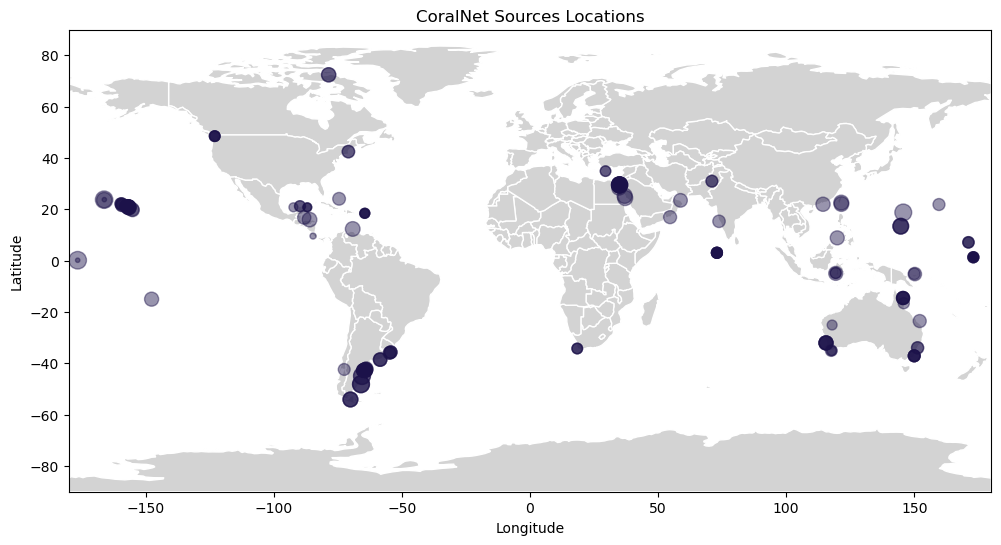

In [38]:
import geopandas as gpd
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

coords = metadata_values_df.copy()
coords["Longitude"] = pd.to_numeric(coords["Longitude"], errors="coerce")
coords["Latitude"] = pd.to_numeric(coords["Latitude"], errors="coerce")
coords = coords.dropna(subset=["Longitude", "Latitude"])

fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color="lightgray", edgecolor="white")

counts = pd.to_numeric(coords["images_folder_count"], errors="coerce").fillna(0)
log_counts = np.log1p(counts)
sizes = 10 + 150 * (log_counts / log_counts.max() if log_counts.max() > 0 else 0)

ax.scatter(
    coords["Longitude"],
    coords["Latitude"],
    s=sizes,
    c="#1C124A",
    alpha=0.45,
)

ax.set_title("CoralNet Sources Locations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
plt.show()

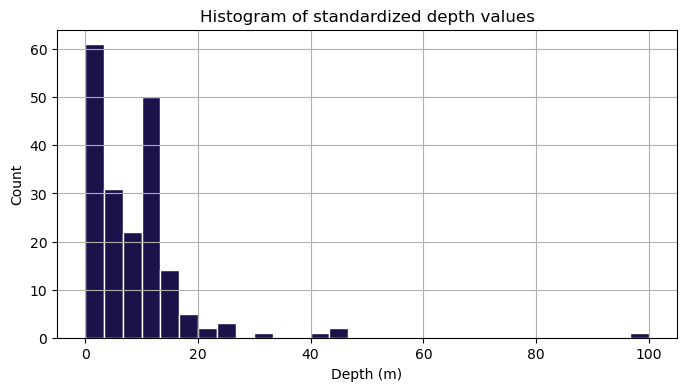

In [12]:
import re

def depth_to_meters(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    # Numeric value with no unit -> assume meters
    if re.fullmatch(r"\d+(\.\d+)?", s):
        return float(s)

    # Ranges like "5-7 meters" or "7-8 Feet"
    m = re.search(r"(\d+(\.\d+)?)\s*[-–]\s*(\d+(\.\d+)?)", s)
    if m:
        v1 = float(m.group(1))
        v2 = float(m.group(3))
        val = (v1 + v2) / 2
    else:
        m = re.search(r"(\d+(\.\d+)?)", s)
        if not m:
            return np.nan
        val = float(m.group(1))

    if any(u in s for u in ["feet", "foot", "ft"]):
        return val * 0.3048

    return val

metadata_values_df["Depth_m"] = metadata_values_df["Depth"].apply(depth_to_meters)

fig, ax = plt.subplots(figsize=(8, 4))
metadata_values_df["Depth_m"].dropna().hist(bins=30, edgecolor="white", ax=ax, color="#1C124A")
ax.set_xlabel("Depth (m)")
ax.set_ylabel("Count")
ax.set_title("Histogram of standardized depth values")
plt.show()

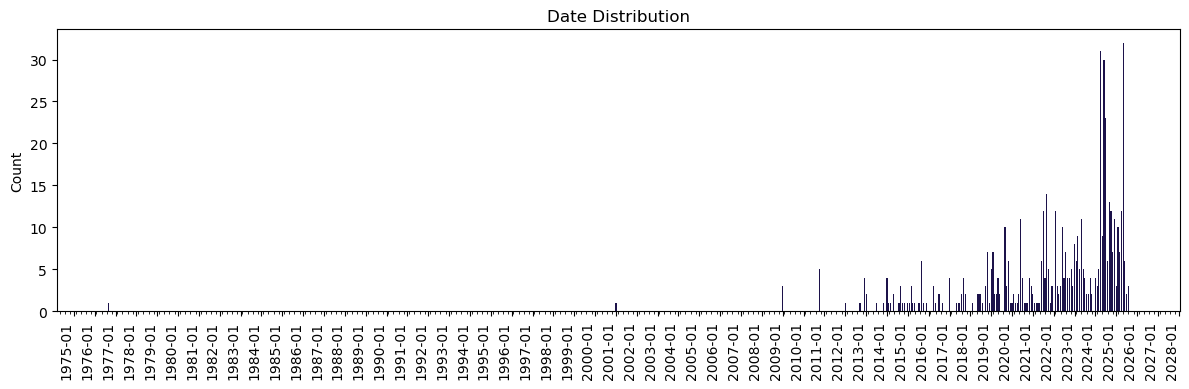

In [10]:
from matplotlib import dates as mdates

dates = pd.to_datetime(metadata_values_df["Date"], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(12, 4))
dates.dt.to_period("M").value_counts().sort_index().plot(kind="bar", ax=ax, color="#1C124A")
monthly_counts = (
    dates.dt.to_period("M")
    .dt.to_timestamp()
    .value_counts()
    .sort_index()
)

ax.clear()
ax.bar(monthly_counts.index, monthly_counts.values, color="#1C124A", width=20)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()
ax.set_ylabel("Count")
ax.set_title("Date Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

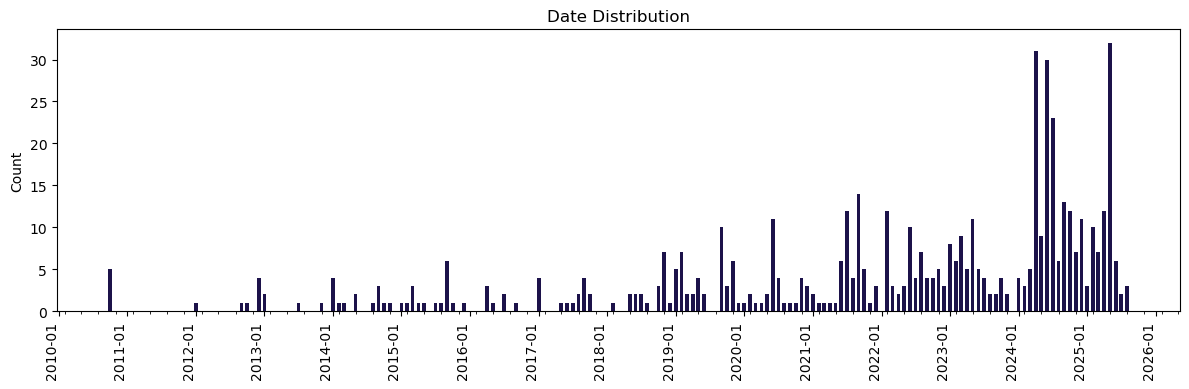

<Figure size 640x480 with 0 Axes>

In [12]:
dates = pd.to_datetime(metadata_values_df["Date"], errors="coerce").dropna()
dates = dates[dates >= "2010-01-01"]

monthly_counts = dates.dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_counts.index, monthly_counts.values, color="#1C124A", width=20)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()
ax.set_ylabel("Count")
ax.set_title("Date Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()